In [54]:
import sounddevice as sd

print(sd.query_devices())
print(sd.query_hostapis())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Analogue 1 + 2 (8- Focusrite US, MME (8 in, 0 out)
   2 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Speakers (8- Focusrite USB Audi, MME (0 in, 8 out)
   5 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   6 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   7 Analogue 1 + 2 (8- Focusrite USB Audio), Windows DirectSound (8 in, 0 out)
   8 Microphone Array (Intel® Smart Sound Technology (Intel® SST)), Windows DirectSound (4 in, 0 out)
   9 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  10 Speakers (8- Focusrite USB Audio), Windows DirectSound (0 in, 8 out)
  11 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  12 Focusrite USB ASIO, ASIO (20 in, 8 out)
  13 Speakers (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
  14 Speakers (8- Focusrite USB Audio), Windows WASAPI (0 in, 2 out)
  15 Microphone Array (Intel® Smart So

In [ ]:
import soundfile as sf
from src.audio_device import AudioDevice

In [8]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
ad = AudioDevice(in_device=1, out_device=4)


In [3]:
len(arthur) / fs

4.975708333333333

In [4]:
ad.play(left=arthur)

(array([ 0.0000000e+00, -3.0517578e-05,  0.0000000e+00, ...,
        -6.1035156e-04, -6.1035156e-04, -6.4086914e-04],
       shape=(238834,), dtype=float32),
 array([ 0.        ,  0.        ,  0.        , ..., -0.00601196,
        -0.00610352, -0.00616455], shape=(238834,), dtype=float32))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
click = np.zeros(fs, dtype=np.float32)
click[100] = 1.0

## Both cores, size 32

In [21]:
error_mic, ref_mic = ad.play(left=click)

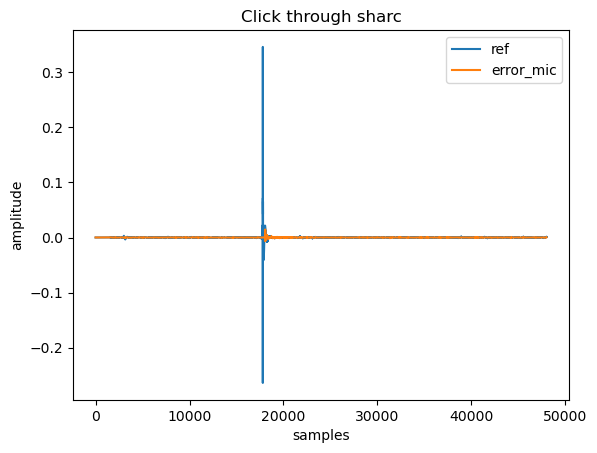

In [22]:
plt.plot(ref_mic, label='ref')
plt.plot(error_mic, label='error_mic')

plt.xlabel('samples')
plt.ylabel('amplitude')
plt.title('Click through sharc')
plt.legend()
plt.show()

In [23]:
ref = ref_mic - np.mean(ref_mic)
err = error_mic - np.mean(error_mic)

corr = np.correlate(err, ref, mode="full")

lag = np.argmax(np.abs(corr)) - (len(ref) - 1)

print(f"Delay: {lag} samples")
print(f"Delay: {1000*lag/48000:.3f} ms")

Delay: 258 samples
Delay: 5.375 ms


In [4]:
def click_measure():
    error_mic, ref_mic = ad.play(left=click)


    ref_idx = np.argmax(np.abs(ref_mic))
    err_idx = np.argmax(np.abs(error_mic))

    delay_samples = err_idx - ref_idx
    delay_ms = 1000 * delay_samples / 48_000

    print(f"Relative delay: {delay_samples} samples")
    print(f"Relative delay: {delay_ms:.3f} ms")

    plt.plot(ref_mic, label='ref')
    plt.plot(error_mic, label='error_mic')

    plt.xlabel('samples')
    plt.ylabel('amplitude')
    plt.title('Click through sharc')
    plt.legend()
    plt.show()

## 2 cores size 32

Relative delay: 258 samples
Relative delay: 5.375 ms


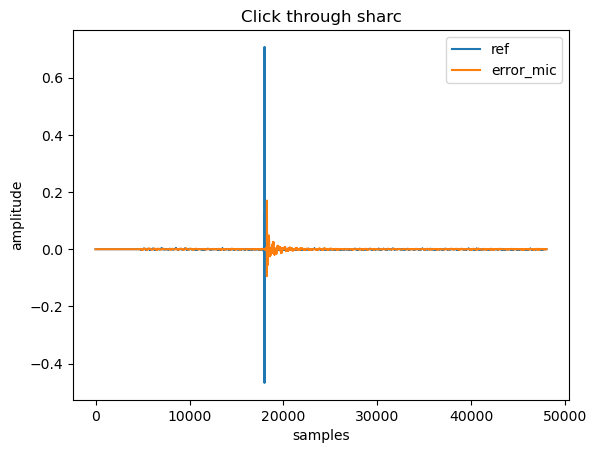

In [119]:
click_measure()

## 2 cores size 16

Relative delay: 179 samples
Relative delay: 3.729 ms


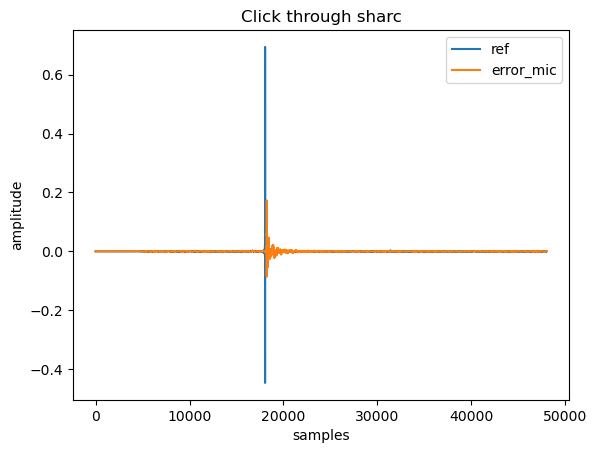

In [116]:
click_measure()

## 2 cores size 8

Relative delay: 138 samples
Relative delay: 2.875 ms


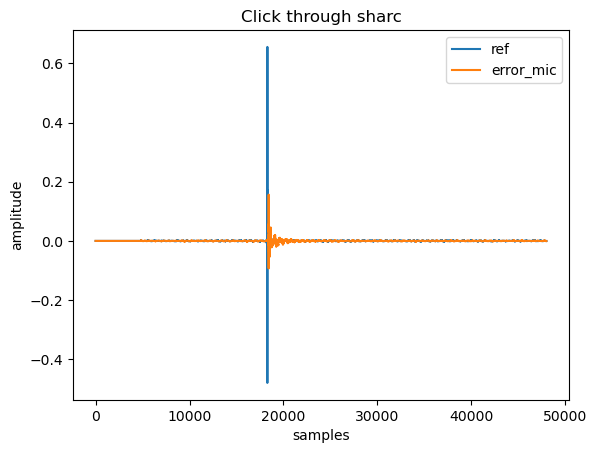

In [113]:
click_measure()

## 1 Core size 32

Relative delay: 193 samples
Relative delay: 4.021 ms


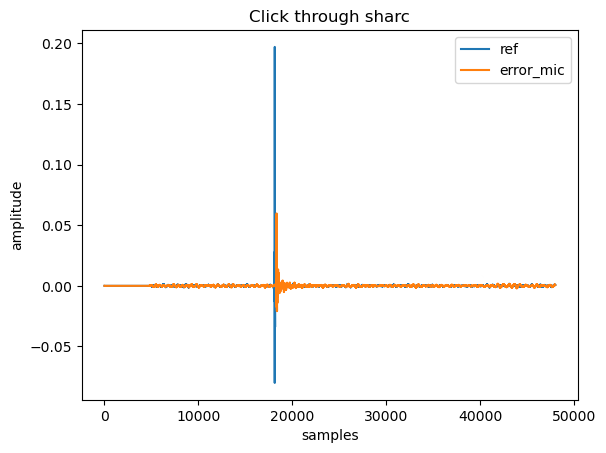

In [106]:
click_measure()

## 1 core size 16

Relative delay: 146 samples
Relative delay: 3.042 ms


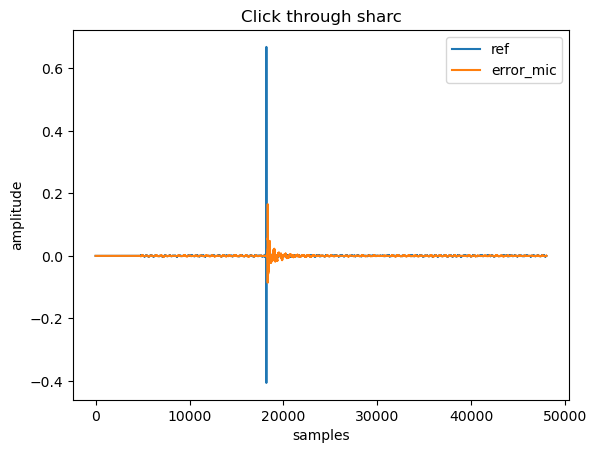

In [108]:
click_measure()

## 1 core size 8

Relative delay: 122 samples
Relative delay: 2.542 ms


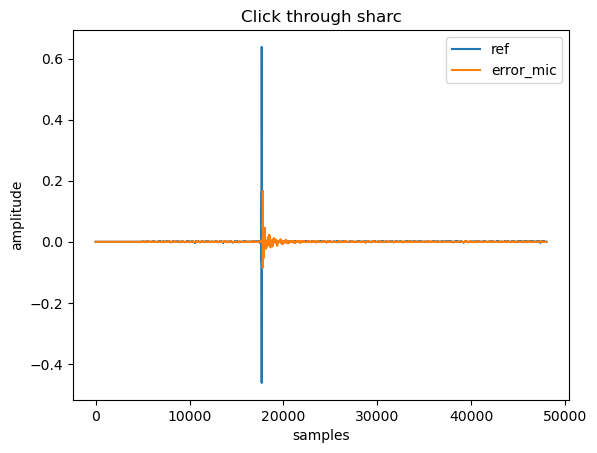

In [111]:
click_measure()

In [14]:
def click_measure():
    error_mic, ref_mic = ad.play(left=click, right=click)


    ref_idx = np.argmax(np.abs(ref_mic))
    err_idx = np.argmax(np.abs(error_mic))

    delay_samples = err_idx - ref_idx
    delay_ms = 1000 * delay_samples / 48_000

    print(f"Relative delay: {delay_samples} samples")
    print(f"Relative delay: {delay_ms:.3f} ms")

    plt.plot(error_mic, label='error_mic')
    plt.plot(ref_mic, label='ref')

    plt.xlabel('samples')
    plt.ylabel('amplitude')
    plt.title('Click through sharc')
    plt.legend()
    plt.show()

## 64

Relative delay: 242 samples
Relative delay: 5.042 ms


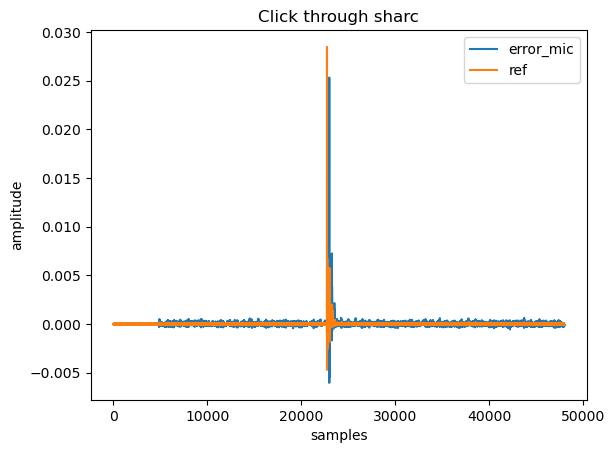

In [24]:
click_measure()

## 32

Relative delay: 147 samples
Relative delay: 3.062 ms


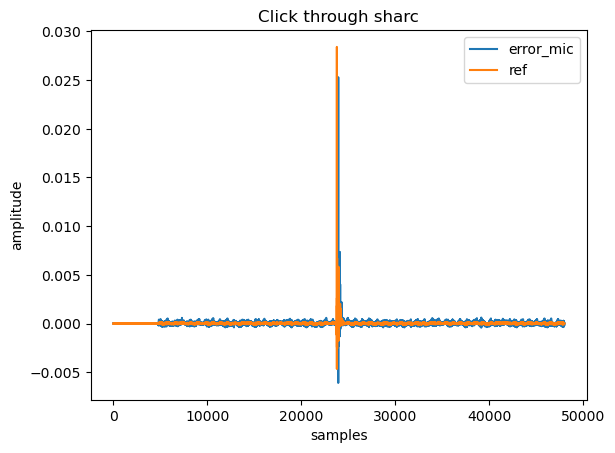

In [23]:
click_measure()

## 16

Relative delay: 99 samples
Relative delay: 2.062 ms


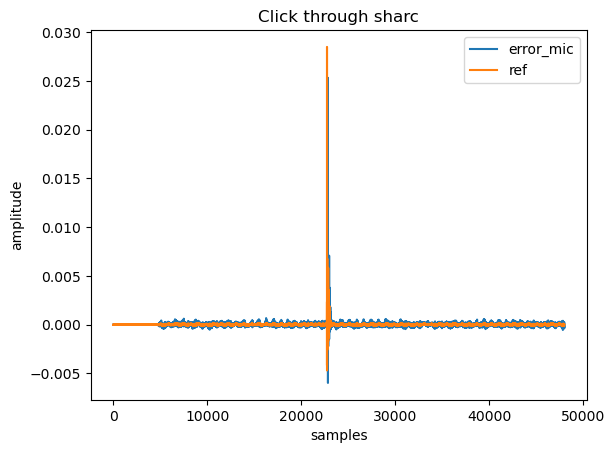

In [22]:
click_measure()

## 1 core, 8 samples, direct test

Relative delay: 74 samples
Relative delay: 1.542 ms


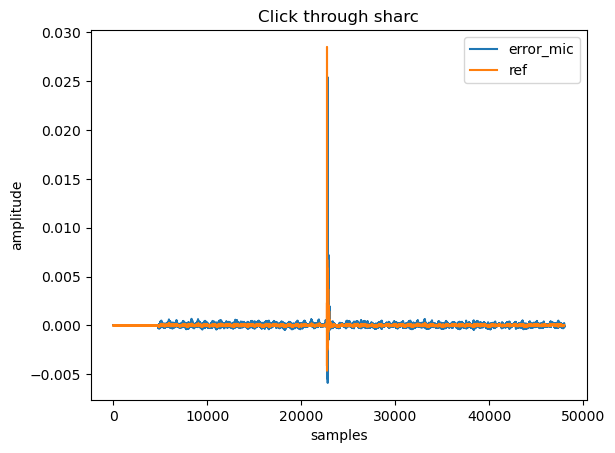

In [20]:
click_measure()

## 1 core, 4 samples, direct test

Relative delay: 62 samples
Relative delay: 1.292 ms


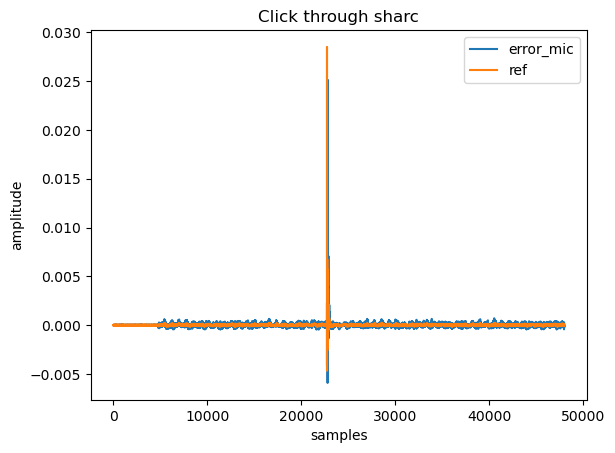

In [19]:
click_measure()

In [25]:
import soundfile as sf
from src.audio_device import AudioDevice
import numpy as np
import matplotlib.pyplot as plt

In [33]:
fs = 96_000
ad = AudioDevice(fs=fs, in_device=1, out_device=4)

click = np.zeros(fs // 2, dtype=np.float32)
click[0] = 1.0

In [34]:
def click_measure():
    error_mic, ref_mic = ad.play(left=click, right=click)


    ref_idx = np.argmax(np.abs(ref_mic))
    err_idx = np.argmax(np.abs(error_mic))

    delay_samples = err_idx - ref_idx
    delay_ms = 1000 * delay_samples / ad.fs

    print(f"Relative delay: {delay_samples} samples")
    print(f"Relative delay: {delay_ms:.3f} ms")

    plt.plot(error_mic, label='error_mic')
    plt.plot(ref_mic, label='ref')

    plt.xlabel('samples')
    plt.ylabel('amplitude')
    plt.title('Click through sharc')
    plt.legend()
    plt.show()

Relative delay: 50 samples
Relative delay: 0.521 ms


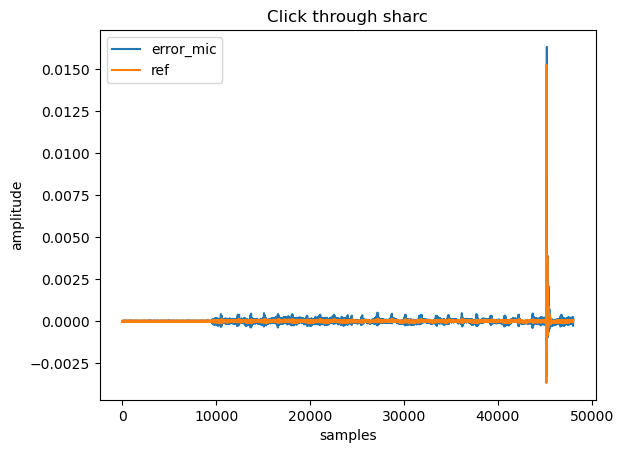

In [35]:
click_measure()

Relative delay: 70 samples
Relative delay: 0.729 ms


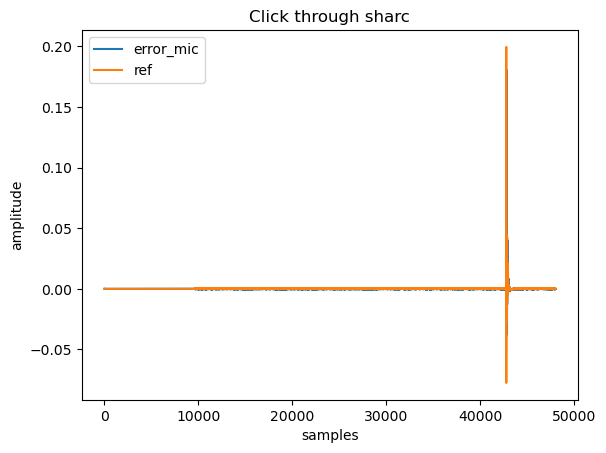

In [39]:
click_measure()

Relative delay: 46 samples
Relative delay: 0.479 ms


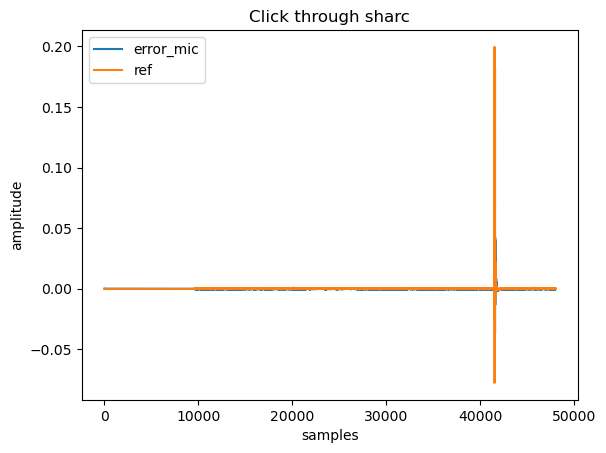

In [44]:
click_measure()

In [59]:
def click_measure():
    error_mic, ref_mic = ad.play(left=click)


    ref_idx = np.argmax(np.abs(ref_mic))
    err_idx = np.argmax(np.abs(error_mic))

    delay_samples = ref_idx - err_idx # in this case ref should be later
    delay_ms = 1000 * delay_samples / ad.fs

    print(f"Relative delay: {delay_samples} samples")
    print(f"Relative delay: {delay_ms:.3f} ms")

    plt.plot(error_mic, label='error_mic')
    plt.plot(ref_mic, label='ref')

    plt.xlabel('samples')
    plt.ylabel('amplitude')
    plt.title('Click through sharc')
    plt.legend()
    plt.show()

Relative delay: 19 samples
Relative delay: 0.198 ms


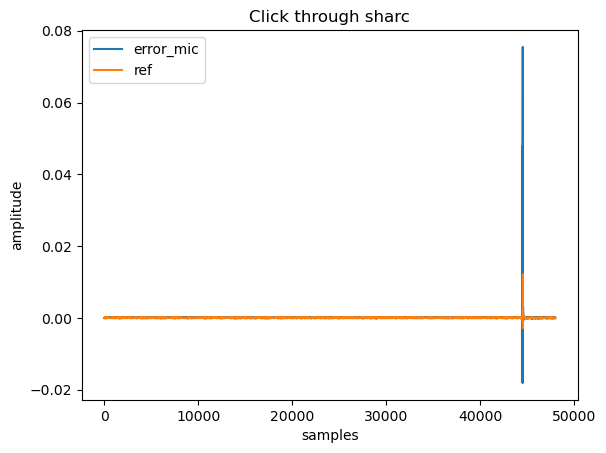

In [51]:
click_measure()

Relative delay: 19 samples
Relative delay: 0.198 ms


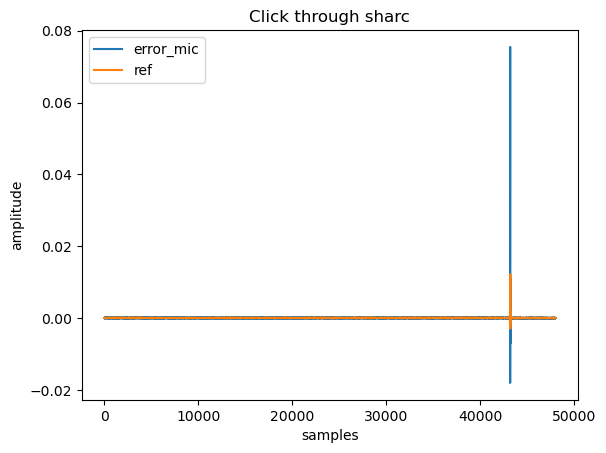

In [61]:
click_measure()

In [55]:
ad = AudioDevice(fs=48_000, in_device=1, out_device=4)

Relative delay: 29 samples
Relative delay: 0.604 ms


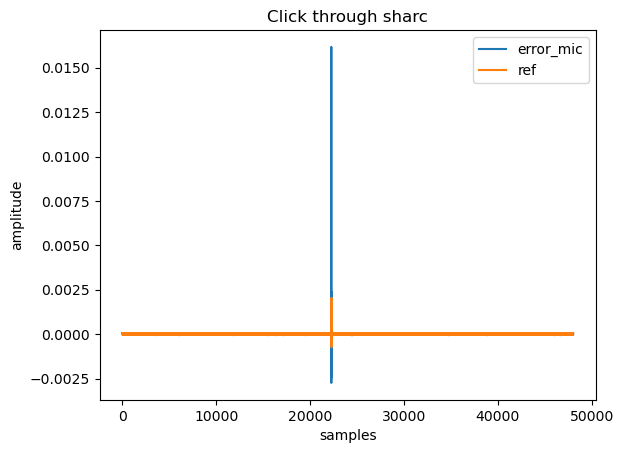

In [57]:
click_measure()

In [1]:
import sounddevice as sd

print(sd.query_devices())
print(sd.query_hostapis())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Analogue 1 + 2 (8- Focusrite US, MME (8 in, 0 out)
   2 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Realtek HD Audio 2nd output (Re, MME (0 in, 2 out)
   5 Speakers (8- Focusrite USB Audi, MME (0 in, 8 out)
   6 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   7 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   8 Analogue 1 + 2 (8- Focusrite USB Audio), Windows DirectSound (8 in, 0 out)
   9 Microphone Array (Intel® Smart Sound Technology (Intel® SST)), Windows DirectSound (4 in, 0 out)
  10 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  11 Realtek HD Audio 2nd output (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  12 Speakers (8- Focusrite USB Audio), Windows DirectSound (0 in, 8 out)
  13 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  14 Speakers (8- Focusrite USB Audio), Windows WASAPI (0 in, 2 out)
  1

In [2]:
import soundfile as sf
from src.audio_device import AudioDevice
import numpy as np
import matplotlib.pyplot as plt

In [3]:
fs = 96_000
ad = AudioDevice(fs=fs, in_device=1, out_device=4)

click = np.zeros(fs // 2, dtype=np.float32)
click[0] = 1.0

In [ ]:
err_dist_cm = 4.5

In [4]:
def click_measure():
    error_mic, ref_mic = ad.play(left=click)


    ref_idx = np.argmax(np.abs(ref_mic))
    err_idx = np.argmax(np.abs(error_mic))

    delay_samples = err_idx - ref_idx # in this case ref should be later
    delay_ms = 1000 * delay_samples / ad.fs

    print(f"Relative delay: {delay_samples} samples")
    print(f"Relative delay: {delay_ms:.3f} ms")

    plt.plot(ref_mic, label='ref')
    plt.plot(error_mic, label='error_mic')

    plt.xlabel('samples')
    plt.ylabel('amplitude')
    plt.title('Click through sharc')
    plt.legend()
    plt.show()
    return error_mic, ref_mic, err_idx, ref_idx

Relative delay: 94 samples
Relative delay: 0.979 ms


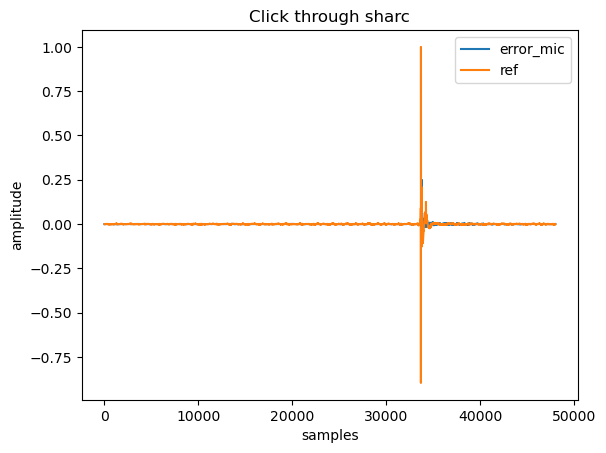

In [19]:
err_mic, ref_mic, err_idx, ref_idx = click_measure()

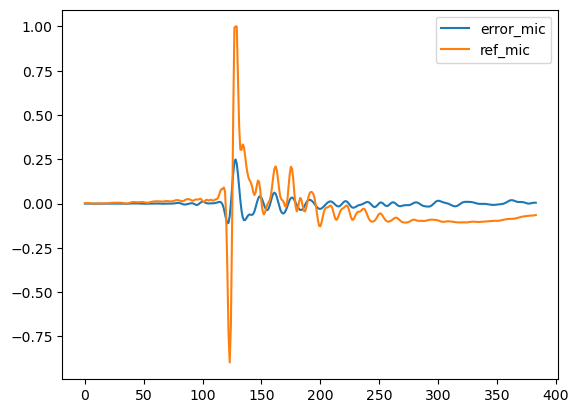

In [21]:
plt.plot(err_mic[err_idx-128:err_idx+256], label="error_mic")
plt.plot(ref_mic[ref_idx-128:ref_idx+256], label="ref_mic")
plt.legend()
plt.show()

In [23]:
thr = 0.1 * np.max(np.abs(err_mic))
err_first_arrival = np.argmax(np.abs(err_mic) > thr)

err_idx - err_first_arrival


np.int64(10)

Relative delay: 89 samples
Relative delay: 0.927 ms


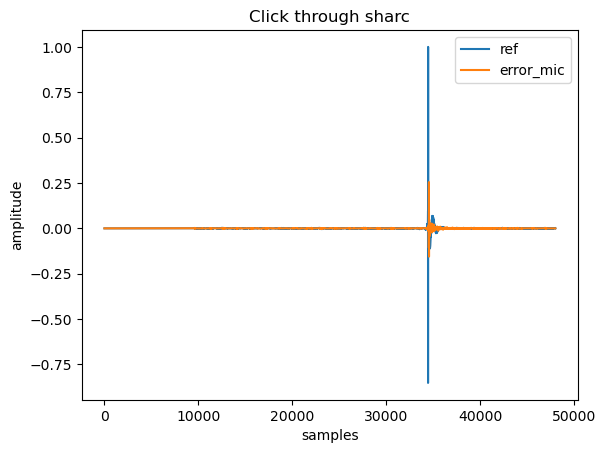

In [16]:
err_mic, ref_mic, err_idx, ref_idx = click_measure()

Relative delay: 88 samples
Relative delay: 0.917 ms


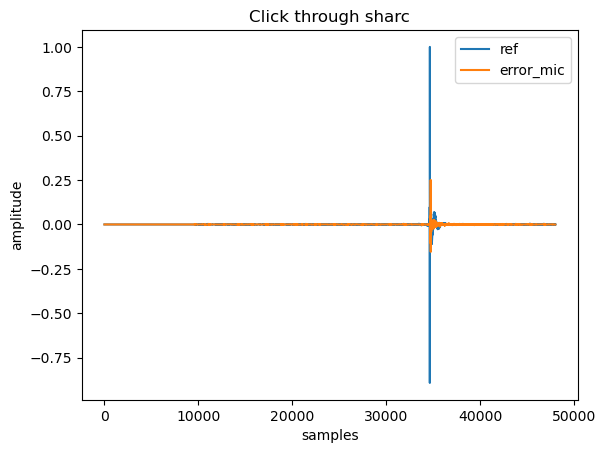

In [27]:
err_mic, ref_mic, err_idx, ref_idx = click_measure()